In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [19]:
athletes = pd.read_csv("data/athlete_events.csv")
regions = pd.read_csv("data/noc_regions.csv")

In [20]:
athletes.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [21]:
regions.head()

,NOC,region,notes
0,AFG,Afghanistan,NaN
1,AHO,Curacao,Netherlands Antilles
2,ALB,Albania,NaN
3,ALG,Algeria,NaN
4,AND,Andorra,NaN


In [23]:
df = pd.merge(athletes,regions,on="NOC")

In [24]:
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,Netherlands,NaN


In [25]:
df.shape

(270767, 17)

In [26]:
df.duplicated().sum()

np.int64(1385)

In [27]:
df.drop_duplicates(inplace=True)

In [28]:
df.isnull().sum()

ID             0
Name           0
Sex            0
Age         9303
Height     58726
Weight     61437
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     229619
region        21
notes     264347
dtype: int64

In [29]:
df["Medal"].unique()

<StringArray>
[nan, 'Gold', 'Bronze', 'Silver']
Length: 4, dtype: str

In [30]:
df["Medal"].fillna("No_Medal" , inplace=True)

C:\Users\MS\AppData\Local\Temp\ipykernel_3168\1001144945.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Medal"].fillna("No_Medal" , inplace=True)


0         No_Medal
1         No_Medal
2         No_Medal
3             Gold
4         No_Medal
            ...   
270762    No_Medal
270763    No_Medal
270764    No_Medal
270765    No_Medal
270766    No_Medal
Name: Medal, Length: 269382, dtype: str

In [31]:
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,Netherlands,NaN


In [32]:
df["Season"].value_counts()

Season
Summer    220818
Winter     48564
Name: count, dtype: int64

In [33]:
summer = df[df["Season"] == "Summer"]
winter = df[df["Season"] == "Winter"]

In [34]:
summer.shape

(220818, 17)

In [35]:
winter.shape

(48564, 17)

#### 1. Season-Wise Medal TAlly

In [36]:
medal_counts_summer = summer.groupby(["NOC","Medal"]).size().reset_index(name="count")

In [37]:
medal_counts_summer

,NOC,Medal,count
0,AFG,Bronze,2
1,AHO,Silver,1
2,ALG,Bronze,8
3,ALG,Gold,5
4,ALG,Silver,4
...,...,...,...
350,ZAM,Bronze,1
351,ZAM,Silver,1
352,ZIM,Bronze,1
353,ZIM,Gold,17


In [38]:
medal_pivot_summer = medal_counts_summer.pivot(index="NOC" , columns="Medal", values="count").fillna(0)

In [39]:
medal_pivot_summer

Medal,Bronze,Gold,Silver
NOC,,,
AFG,2.0,0.0,0.0
AHO,0.0,0.0,1.0
ALG,8.0,5.0,4.0
ANZ,5.0,20.0,4.0
ARG,91.0,91.0,92.0
...,...,...,...
VIE,0.0,1.0,3.0
WIF,5.0,0.0,0.0
YUG,92.0,130.0,161.0


In [40]:
medal_pivot_summer = medal_pivot_summer.astype(int)

In [41]:
medal_pivot_summer

Medal,Bronze,Gold,Silver
NOC,,,
AFG,2,0,0
AHO,0,0,1
ALG,8,5,4
ANZ,5,20,4
ARG,91,91,92
...,...,...,...
VIE,0,1,3
WIF,5,0,0
YUG,92,130,161


In [42]:
medal_pivot_summer["Total_medal"] = medal_pivot_summer[["Gold","Silver","Bronze"]].sum(axis=1)

In [43]:
medal_pivot_summer

Medal,Bronze,Gold,Silver,Total_medal
NOC,,,,
AFG,2,0,0,2
AHO,0,0,1,1
ALG,8,5,4,17
ANZ,5,20,4,29
ARG,91,91,92,274
...,...,...,...,...
VIE,0,1,3,4
WIF,5,0,0,5
YUG,92,130,161,383


In [44]:
medal_pivot_summer.sort_values(by=["Gold","Silver","Bronze"] , ascending=False).head(30)

Medal,Bronze,Gold,Silver,Total_medal
NOC,,,,
USA,1197,2472,1333,5002
URS,596,832,635,2063
GBR,620,635,729,1984
GER,649,592,538,1779
ITA,454,518,474,1446
FRA,587,463,567,1617
HUN,363,432,328,1123
SWE,358,354,396,1108
AUS,510,342,452,1304


In [45]:
summer.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN
26,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,NaN,Netherlands,NaN


In [46]:
summer.shape

(220818, 17)

In [47]:
summer = summer.drop_duplicates(subset=["Team","NOC","Games","Year","City","Sport","Event"])

In [48]:
summer.shape

(98657, 17)

In [49]:
winter = winter.drop_duplicates(subset=["Team","NOC","Games","Year","City","Sport","Event"])

In [50]:
winter.shape

(16956, 17)

In [51]:
medal_counts_winter = winter.groupby(["NOC","Medal"]).size().reset_index(name="count")

In [52]:
medal_pivot_winter = medal_counts_winter.pivot(index="NOC" , columns="Medal", values="count").fillna(0)

In [53]:
medal_pivot_winter

Medal,Bronze,Gold,Silver
NOC,,,
AUS,4.0,5.0,3.0
AUT,24.0,21.0,31.0
BEL,3.0,1.0,1.0
BLR,3.0,3.0,2.0
BUL,0.0,1.0,1.0
CAN,25.0,43.0,34.0
CHN,12.0,5.0,8.0
CRO,1.0,1.0,5.0
CZE,5.0,6.0,5.0


In [54]:
medal_pivot_winter = medal_pivot_winter.astype(int)

In [55]:
medal_pivot_winter["Total_medal"] = medal_pivot_winter[["Gold","Silver","Bronze"]].sum(axis=1)

In [56]:
medal_pivot_winter.sort_values(by=["Gold","Silver","Bronze"] , ascending=False).head(30)

Medal,Bronze,Gold,Silver,Total_medal
NOC,,,,
NOR,48,58,43,149
URS,24,46,24,94
CAN,25,43,34,102
USA,44,39,48,131
GER,36,39,38,113
RUS,21,28,22,71
SWE,31,23,22,76
AUT,24,21,31,76
ITA,25,19,17,61


In [57]:
medal_pivot_winter

Medal,Bronze,Gold,Silver,Total_medal
NOC,,,,
AUS,4,5,3,12
AUT,24,21,31,76
BEL,3,1,1,5
BLR,3,3,2,8
BUL,0,1,1,2
CAN,25,43,34,102
CHN,12,5,8,25
CRO,1,1,5,7
CZE,5,6,5,16


In [58]:
### VS CODE ---

###  COUNTRY-WISE MEDAL TALLY

In [59]:
medal_pivot_summer

Medal,Bronze,Gold,Silver,Total_medal
NOC,,,,
AFG,2,0,0,2
AHO,0,0,1,1
ALG,8,5,4,17
ANZ,5,20,4,29
ARG,91,91,92,274
...,...,...,...,...
VIE,0,1,3,4
WIF,5,0,0,5
YUG,92,130,161,383


In [60]:
def fetch_noc(noc,pivot_table):
    if noc in pivot_table.index:
        details ={
            "Gold" : pivot_table.loc[noc,"Gold"],
            "Silver" : pivot_table.loc[noc,"Silver"],
            "Bronze" : pivot_table.loc[noc,"Bronze"],
            "Total Medal" : pivot_table.loc[noc,"Total_medal"]
        }
        return details
    else:
        print("No NOC exist")

In [61]:
fetch_noc("USA" , medal_pivot_summer)

{'Gold': np.int64(2472),
 'Silver': np.int64(1333),
 'Bronze': np.int64(1197),
 'Total Medal': np.int64(5002)}

### YEAR_WISE SEARCH 

In [62]:
summer.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN
26,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,NaN,Netherlands,NaN


In [63]:
summer.shape

(98657, 17)

In [64]:
summer.isnull().sum()

ID            0
Name          0
Sex           0
Age        3119
Height    17827
Weight    18182
Team          0
NOC           0
Games         0
Year          0
Season        0
City          0
Sport         0
Event         0
Medal     87265
region       20
notes     96593
dtype: int64

In [67]:
summer.dropna(subset=["region"] , inplace=True)

In [69]:
summer.shape

(98637, 17)

In [70]:
medals_count = summer.groupby(["Year","region","Medal"]).size().unstack(fill_value=0)

In [71]:
medals_count 

Medal            Bronze  Gold  Silver
Year region                          
1896 Australia        1     2       0
     Austria          2     2       1
     Denmark          3     1       2
     France           2     1       4
     Germany          1     4       1
...                 ...   ...     ...
2016 Tajikistan       0     1       0
     Grenada          0     0       1
     Fiji             0     1       0
     Jordan           0     1       0
     Kosovo           0     1       0

[1224 rows x 3 columns]

In [72]:
medals_count = medals_count.reset_index()

In [73]:
medals_count

Medal,Year,region,Bronze,Gold,Silver
0,1896,Australia,1,2,0
1,1896,Austria,2,2,1
2,1896,Denmark,3,1,2
3,1896,France,2,1,4
4,1896,Germany,1,4,1
...,...,...,...,...,...
1219,2016,Tajikistan,0,1,0
1220,2016,Grenada,0,0,1
1221,2016,Fiji,0,1,0
1222,2016,Jordan,0,1,0


In [91]:
medals_count["Total_Medal"] = medals_count["Gold"] + medals_count["Silver"] + medals_count["Bronze"]

In [92]:
medals_count

Medal,Year,region,Bronze,Gold,Silver,Total_Medal
0,1896,Australia,1,2,0,3
1,1896,Austria,2,2,1,5
2,1896,Denmark,3,1,2,6
3,1896,France,2,1,4,7
4,1896,Germany,1,4,1,6
...,...,...,...,...,...,...
1219,2016,Tajikistan,0,1,0,1
1220,2016,Grenada,0,0,1,1
1221,2016,Fiji,0,1,0,1
1222,2016,Jordan,0,1,0,1


In [93]:
def plot_medals(year , country , df):

    filtered_df = df[(df["Year"]== year) & (df["region"]==country)]
    
    gold = filtered_df["Gold"].values[0]
    silver = filtered_df["Silver"].values[0]
    bronze = filtered_df["Bronze"].values[0]
    total_medal = filtered_df["Total_Medal"].values[0]
    
    fig,ax = plt.subplots()
    medals=["Gold","Silver","Bronze","Total_Medals"]
    counts = [gold , silver , bronze, total_medal]
    ax.bar(medals,counts,color=["gold","silver","brown","green"])
    plt.show()
    



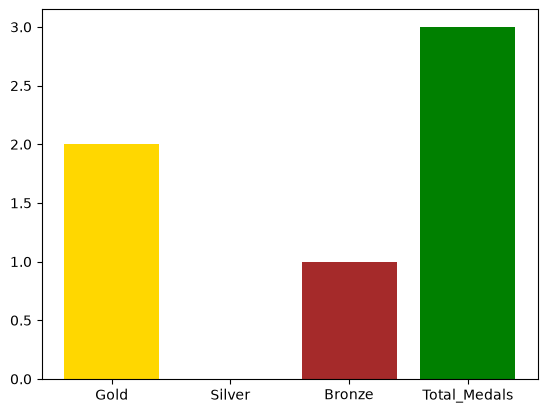

In [94]:
plot_medals(1896,"Australia",medals_count)

### YEAR WISE  PROGRESS OF A COUNTRY

In [95]:
medals_count

Medal,Year,region,Bronze,Gold,Silver,Total_Medal
0,1896,Australia,1,2,0,3
1,1896,Austria,2,2,1,5
2,1896,Denmark,3,1,2,6
3,1896,France,2,1,4,7
4,1896,Germany,1,4,1,6
...,...,...,...,...,...,...
1219,2016,Tajikistan,0,1,0,1
1220,2016,Grenada,0,0,1,1
1221,2016,Fiji,0,1,0,1
1222,2016,Jordan,0,1,0,1


In [96]:
def plot_year_progress(country , df):
    filtered_df = df[df["region"] == country]
    fig,ax = plt.subplots()
    ax.plot(filtered_df["Year"] , filtered_df["Gold"] , color="gold" , label="GOLD" , marker="o" , linestyle="-")
    ax.plot(filtered_df["Year"] , filtered_df["Silver"] , color="silver" , label="SILVER", marker="o" , linestyle="-")
    ax.plot(filtered_df["Year"] , filtered_df["Bronze"] , color="brown" , label="BRONZE", marker="o" , linestyle="-")
    ax.plot(filtered_df["Year"] , filtered_df["Total_Medal"] , color="green" , label="TOTAL MEDALS", marker="o" , linestyle="-")
    ax.legend()
    plt.show()
    
    
    

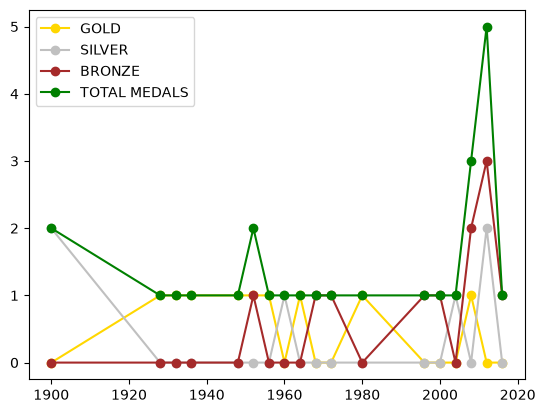

In [97]:
plot_year_progress("India" , medals_count)

In [98]:
summer.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN
26,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,NaN,Netherlands,NaN
